# DepthAnythingV2 Metric Indoor — single image inference
Runs CoreML metric depth on a WhatsApp photo and visualises distances in meters.

In [2]:
import coremltools as ct
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, sys
print('coremltools:', ct.__version__)
print('python:', sys.version.split()[0])

XGBoost version 2.1.4 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
TensorFlow version 2.13.0 has not been tested with coremltools. You may run into unexpected errors. TensorFlow 2.12.0 is the most recent version that has been tested.


coremltools: 9.0
python: 3.8.10


In [3]:
MODEL_PATH = '/Users/christianluisefendy/Documents/AIML_Challenge1_Vision/drivingsim/drivingsim/Models/DepthAnythingV2MetricIndoorSmallF16.mlpackage'
IMG_PATH   = '/Users/christianluisefendy/Documents/AIML_Challenge1_Vision/image.png'
assert os.path.exists(MODEL_PATH), MODEL_PATH
assert os.path.exists(IMG_PATH), IMG_PATH

model = ct.models.MLModel(MODEL_PATH)
spec = model.get_spec()
print('inputs :', [(i.name, i.type.WhichOneof('Type')) for i in spec.description.input])
print('outputs:', [(o.name, o.type.WhichOneof('Type')) for o in spec.description.output])
# inspect image input dims
for i in spec.description.input:
    if i.type.WhichOneof('Type') == 'imageType':
        print('input image:', i.name, i.type.imageType.width, 'x', i.type.imageType.height,
              'colorspace=', i.type.imageType.colorSpace)

inputs : [('image', 'imageType')]
outputs: [('depth', 'imageType')]
input image: image 518 x 518 colorspace= 20


orig size: (1606, 1146) -> model in: (518, 518)


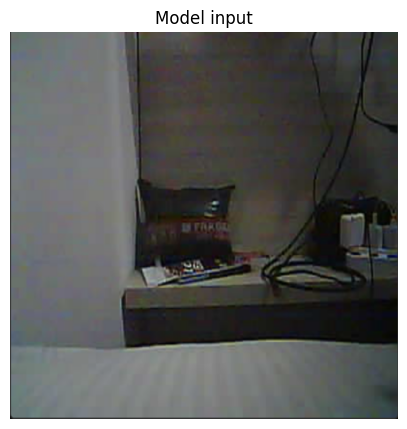

In [4]:
# Load + resize to model input.
img = Image.open(IMG_PATH).convert('RGB')
in_w = in_h = 518
for i in spec.description.input:
    if i.type.WhichOneof('Type') == 'imageType':
        in_w, in_h = i.type.imageType.width, i.type.imageType.height
img_resized = img.resize((in_w, in_h), Image.BICUBIC)
print('orig size:', img.size, '-> model in:', img_resized.size)
plt.figure(figsize=(5,7))
plt.imshow(img_resized); plt.title('Model input'); plt.axis('off'); plt.show()

In [5]:
# Run inference. Apple's metric model accepts PIL Image directly.
in_name = [i.name for i in spec.description.input][0]
out_name = [o.name for o in spec.description.output][0]
print('feeding key:', in_name)
result = model.predict({in_name: img_resized})
depth = result[out_name]
print('output type:', type(depth))
depth = np.array(depth).squeeze()
print('depth shape:', depth.shape, 'dtype:', depth.dtype)
print('depth range: min=%.3f  max=%.3f  mean=%.3f' % (depth.min(), depth.max(), depth.mean()))

feeding key: image
output type: <class 'PIL.Image.Image'>
depth shape: (518, 518) dtype: float32
depth range: min=1.284  max=2.939  mean=2.271


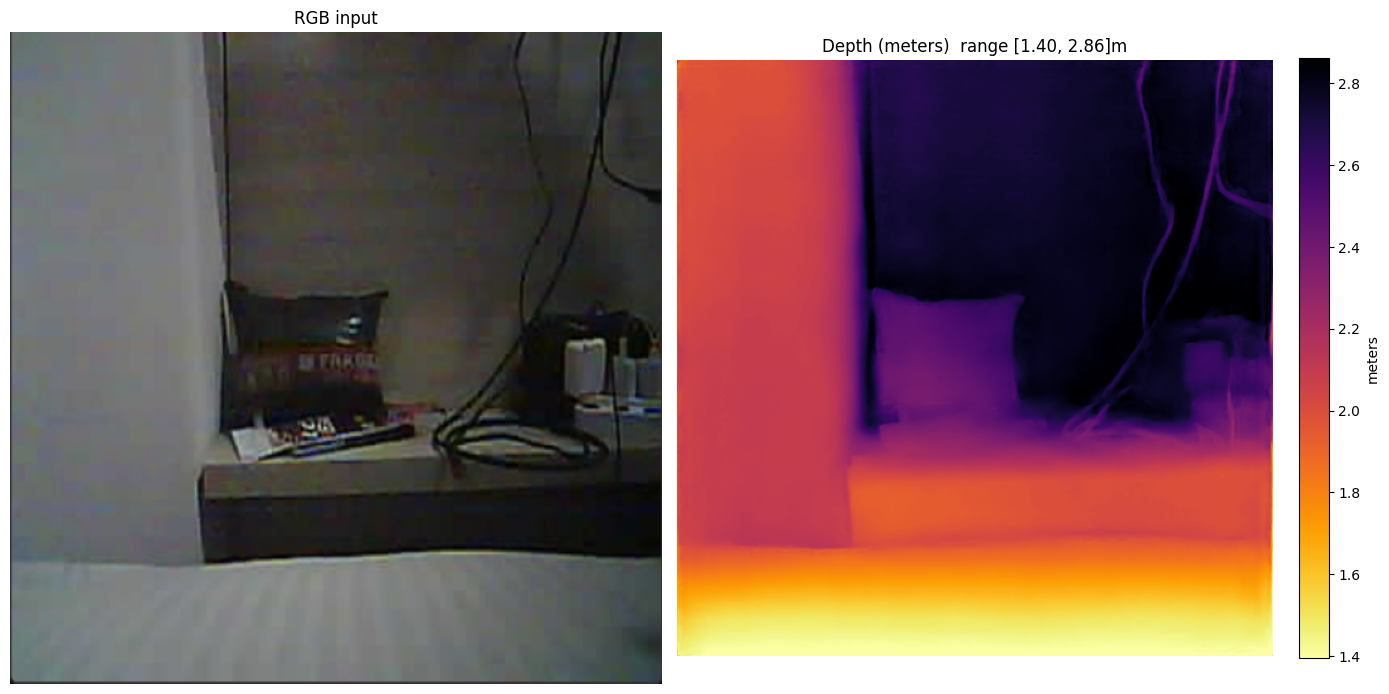

In [6]:
# Visualise — meters colormap (inferno) with colorbar.
# Indoor model trained on Hypersim → ~0-10m range typical.
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(img_resized)
axes[0].set_title('RGB input')
axes[0].axis('off')

vmin, vmax = float(np.percentile(depth, 1)), float(np.percentile(depth, 99))
im = axes[1].imshow(depth, cmap='inferno_r', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Depth (meters)  range [{vmin:.2f}, {vmax:.2f}]m')
axes[1].axis('off')
cb = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label('meters')
plt.tight_layout(); plt.show()

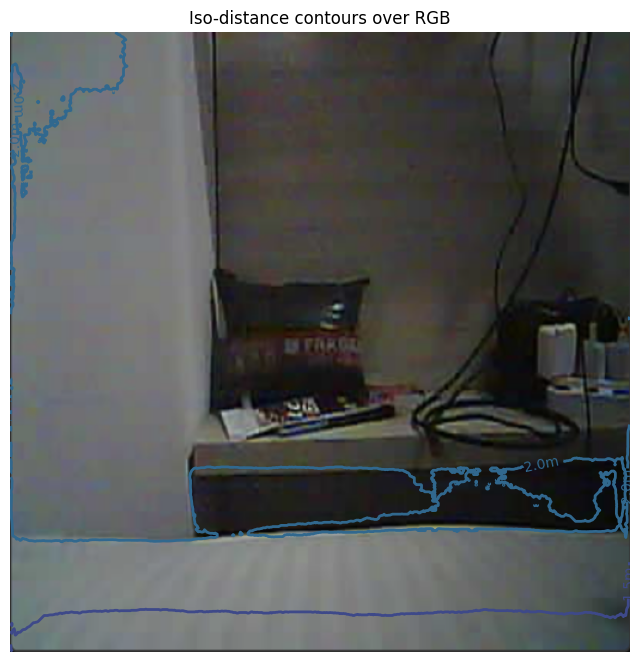

In [7]:
# Overlay: contour iso-distance lines at 1, 2, 3, 5m on top of RGB.
fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img_resized)
levels = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
cs = ax.contour(depth, levels=levels, cmap='viridis', linewidths=2)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1fm')
ax.set_title('Iso-distance contours over RGB')
ax.axis('off'); plt.show()

person torso (center)               pixel=(259,259)  depth= 2.52 m
person face (upper-center)          pixel=(139,259)  depth= 2.77 m
left wall stickies                  pixel=(155, 51)  depth= 2.04 m
whiteboard mid-right                pixel=(155,414)  depth= 2.81 m
floor near camera (bottom)          pixel=(502,259)  depth= 1.43 m
wood cabinet (right-bot)            pixel=(440,404)  depth= 1.80 m


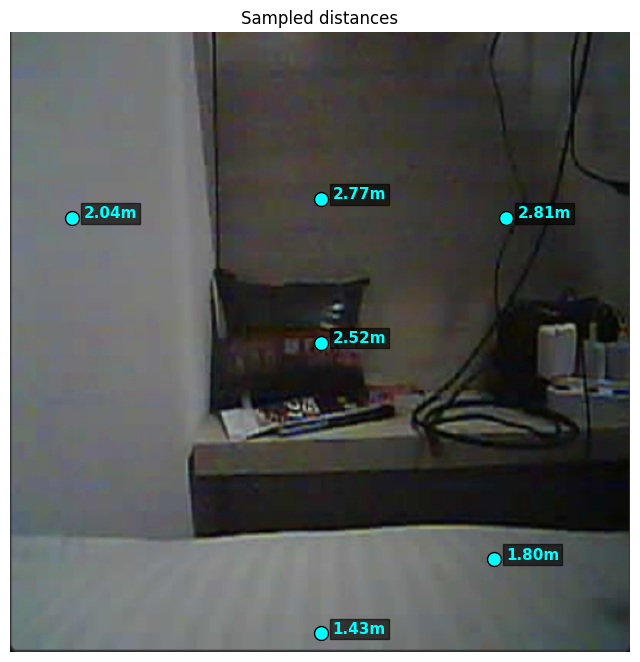

In [8]:
# Point queries: click-style — sample a few interesting pixels and print distance.
H, W = depth.shape
samples = {
    'person torso (center)':       (H//2, W//2),
    'person face (upper-center)':  (int(H*0.27), int(W*0.50)),
    'left wall stickies':          (int(H*0.30), int(W*0.10)),
    'whiteboard mid-right':        (int(H*0.30), int(W*0.80)),
    'floor near camera (bottom)':  (int(H*0.97), int(W*0.50)),
    'wood cabinet (right-bot)':    (int(H*0.85), int(W*0.78)),
}
fig, ax = plt.subplots(figsize=(8,11))
ax.imshow(img_resized)
for label, (r, c) in samples.items():
    d = float(depth[r, c])
    print(f'{label:35s} pixel=({r:3d},{c:3d})  depth={d:5.2f} m')
    ax.plot(c, r, 'o', color='cyan', markersize=10, markeredgecolor='black')
    ax.text(c+10, r, f'{d:.2f}m', color='cyan', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6, pad=2))
ax.set_title('Sampled distances'); ax.axis('off'); plt.show()

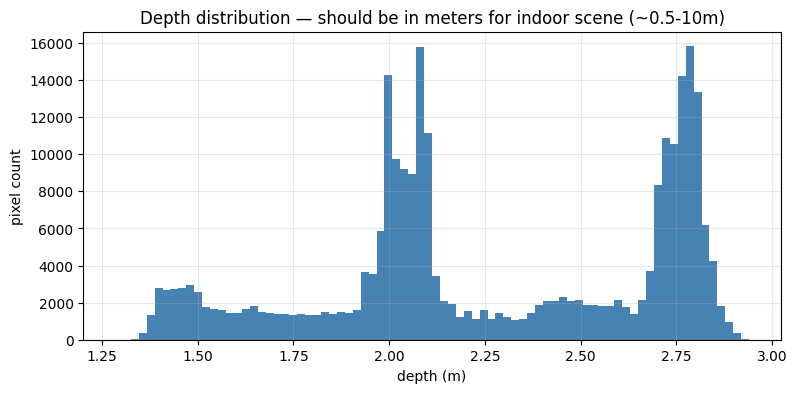

In [9]:
# Histogram of depth values to gauge model output scale.
plt.figure(figsize=(9,4))
plt.hist(depth.flatten(), bins=80, color='steelblue')
plt.xlabel('depth (m)'); plt.ylabel('pixel count')
plt.title('Depth distribution — should be in meters for indoor scene (~0.5-10m)')
plt.grid(alpha=0.3); plt.show()

# 2D BEV (top-down) reconstruction

Unproject every depth pixel through pinhole intrinsics → 3D camera-frame points → drop ceiling/floor → bird's-eye-view (X, Z) plane.

Assumed intrinsics: square sensor, HFOV ≈ 70° (typical phone main camera). Adjust `HFOV_DEG` if needed.

In [10]:
# ── Camera intrinsics + unprojection ─────────────────────────────────────
HFOV_DEG = 70.0          # phone wide-cam estimate — tweak if scale looks off
MAX_RANGE_M = 6.0        # drop hits beyond this (model unreliable + noisy)
MIN_RANGE_M = 0.3        # drop hits closer than this (model noise floor)

# Height filter (camera-frame Y, +Y = DOWN in image-pixel convention).
# Keep mid-band: not ceiling, not floor. Assume camera ~1.4m off ground,
# obstacles span -0.6..+0.9 around eye line.
Y_MIN, Y_MAX = -0.6, 0.9

H, W = depth.shape
cx, cy = W / 2.0, H / 2.0
fx = cx / np.tan(np.deg2rad(HFOV_DEG) / 2.0)
fy = fx   # assume square pixels
print(f'intrinsics: W={W} H={H}  fx=fy={fx:.1f}  cx={cx} cy={cy}  HFOV={HFOV_DEG} deg')

us, vs = np.meshgrid(np.arange(W), np.arange(H))
Z = depth.astype(np.float32)
Xc = (us - cx) * Z / fx
Yc = (vs - cy) * Z / fy
# Camera frame: +X right, +Y down, +Z forward.

rgb_np = np.asarray(img_resized, dtype=np.float32) / 255.0

mask = (Z >= MIN_RANGE_M) & (Z <= MAX_RANGE_M) & (Yc >= Y_MIN) & (Yc <= Y_MAX)
print(f'kept {mask.sum():,} / {mask.size:,} pixels  ({100*mask.mean():.1f}%)')

Xf = Xc[mask]
Zf = Z[mask]
Yf = Yc[mask]
Cf = rgb_np.reshape(-1, 3)[mask.flatten()]
print(f'X range [{Xf.min():.2f}, {Xf.max():.2f}] m')
print(f'Z range [{Zf.min():.2f}, {Zf.max():.2f}] m')
print(f'Y range [{Yf.min():.2f}, {Yf.max():.2f}] m  (filtered band)')

intrinsics: W=518 H=518  fx=fy=369.9  cx=259.0 cy=259.0  HFOV=70.0 deg
kept 146,473 / 268,324 pixels  (54.6%)
X range [-1.47, 2.03] m
Z range [1.28, 2.94] m
Y range [-0.60, 0.90] m  (filtered band)


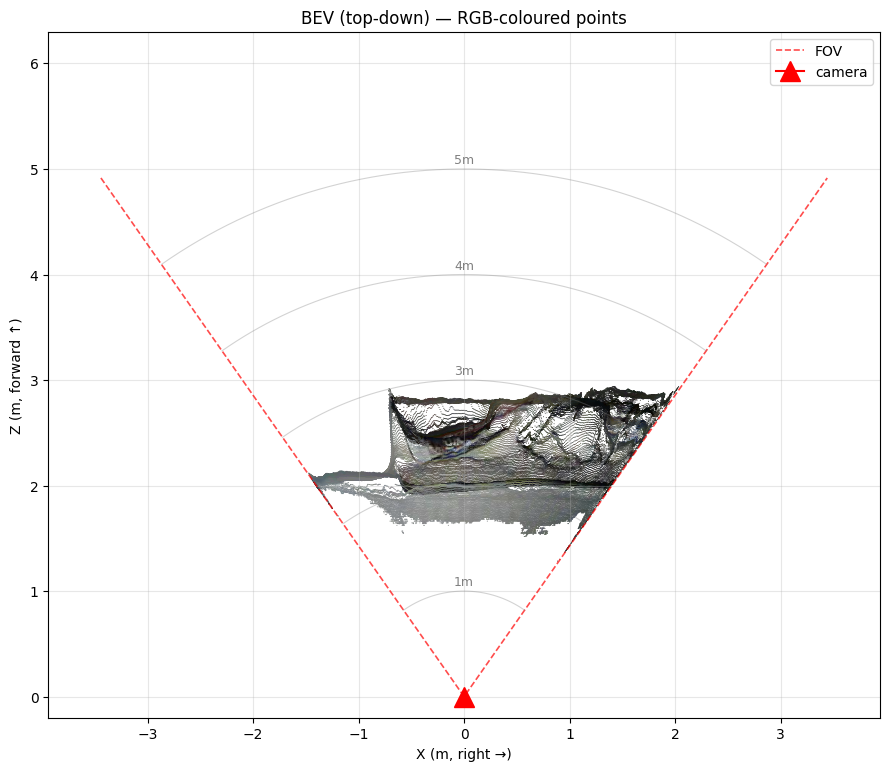

In [11]:
# ── BEV scatter — points coloured by original RGB ────────────────────────
# Camera at origin, looking up the page (+Z).  X right, Z forward.
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(Xf, Zf, c=Cf, s=2, marker='.', linewidths=0)

# Camera glyph + FOV cone.
fov_half = np.deg2rad(HFOV_DEG) / 2.0
cone_x = [MAX_RANGE_M * np.sin(-fov_half), 0, MAX_RANGE_M * np.sin(fov_half)]
cone_z = [MAX_RANGE_M * np.cos(-fov_half), 0, MAX_RANGE_M * np.cos( fov_half)]
ax.plot(cone_x, cone_z, '--', color='red', linewidth=1.2, alpha=0.7, label='FOV')
ax.plot(0, 0, marker='^', color='red', markersize=14, label='camera')

# Iso-range rings.
for r in [1, 2, 3, 4, 5]:
    theta = np.linspace(-fov_half, fov_half, 60)
    ax.plot(r*np.sin(theta), r*np.cos(theta), color='gray', alpha=0.35, linewidth=0.8)
    ax.text(0, r+0.05, f'{r}m', color='gray', ha='center', fontsize=9)

ax.set_xlabel('X (m, right →)'); ax.set_ylabel('Z (m, forward ↑)')
ax.set_title('BEV (top-down) — RGB-coloured points')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(loc='upper right')
ax.set_xlim(-MAX_RANGE_M*np.sin(fov_half)-0.5, MAX_RANGE_M*np.sin(fov_half)+0.5)
ax.set_ylim(-0.2, MAX_RANGE_M+0.3)
plt.tight_layout(); plt.show()

grid: (160, 120)  total hits: 146473  occupied cells: 1285


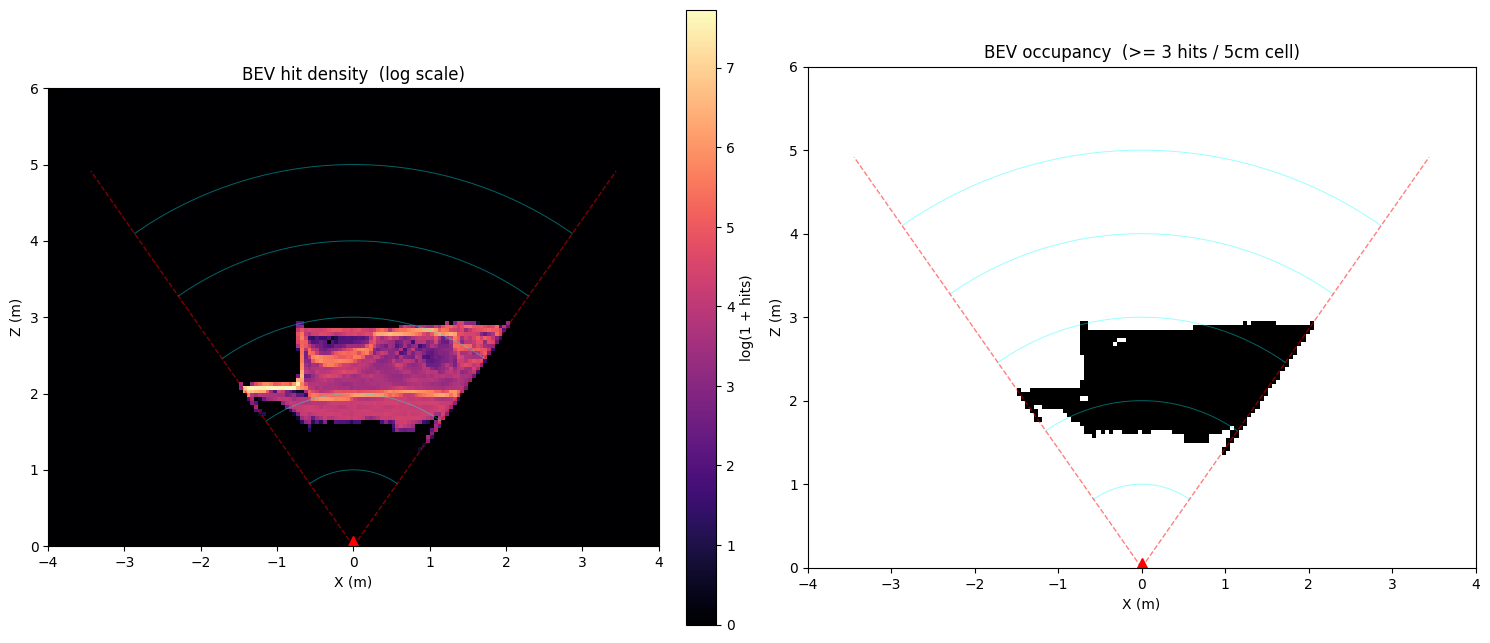

In [12]:
# ── BEV occupancy grid — 2D histogram of hits per (X, Z) cell ────────────
CELL_M = 0.05            # 5cm grid
GRID_HALF_X = 4.0        # ±4m around camera
GRID_Z_MAX = MAX_RANGE_M

x_edges = np.arange(-GRID_HALF_X, GRID_HALF_X + CELL_M, CELL_M)
z_edges = np.arange(0,            GRID_Z_MAX  + CELL_M, CELL_M)
hist, xe, ze = np.histogram2d(Xf, Zf, bins=[x_edges, z_edges])
# Threshold: cells with ≥N hits = OCCUPIED. Picks out walls + person silhouette.
OCC_HITS = 3
occ = (hist >= OCC_HITS).astype(np.uint8)
print('grid:', hist.shape, ' total hits:', int(hist.sum()),
      ' occupied cells:', int(occ.sum()))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Left: raw hit density (log scale).
im0 = axes[0].imshow(np.log1p(hist.T), origin='lower',
                     extent=[x_edges[0], x_edges[-1], z_edges[0], z_edges[-1]],
                     cmap='magma', aspect='equal')
axes[0].set_title('BEV hit density  (log scale)')
axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Z (m)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='log(1 + hits)')

# Right: thresholded occupancy.
im1 = axes[1].imshow(occ.T, origin='lower',
                     extent=[x_edges[0], x_edges[-1], z_edges[0], z_edges[-1]],
                     cmap='gray_r', aspect='equal')
axes[1].set_title(f'BEV occupancy  (>= {OCC_HITS} hits / {int(CELL_M*100)}cm cell)')
axes[1].set_xlabel('X (m)'); axes[1].set_ylabel('Z (m)')

for ax in axes:
    ax.plot(0, 0, marker='^', color='red', markersize=14)
    theta = np.linspace(-fov_half, fov_half, 60)
    for r in [1, 2, 3, 4, 5]:
        ax.plot(r*np.sin(theta), r*np.cos(theta), color='cyan', alpha=0.4, linewidth=0.7)
    ax.plot([0, MAX_RANGE_M*np.sin(-fov_half)], [0, MAX_RANGE_M*np.cos(fov_half)],
            '--', color='red', alpha=0.5, linewidth=1)
    ax.plot([0, MAX_RANGE_M*np.sin( fov_half)], [0, MAX_RANGE_M*np.cos(fov_half)],
            '--', color='red', alpha=0.5, linewidth=1)
plt.tight_layout(); plt.show()

/var/folders/hy/rtkj7_ms0yb77p07f6t4tmzr0000gn/T/ipykernel_34359/4066517443.py:26: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax_p = plt.subplot(1, 2, 2, projection='polar')


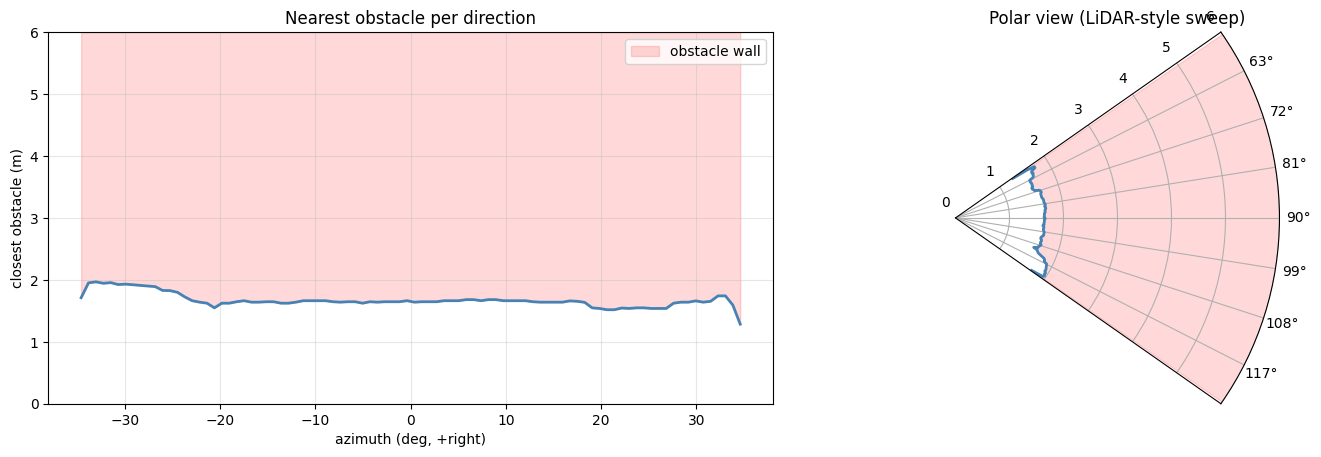

In [13]:
# ── Polar BEV: angle × range — closest obstacle per direction ────────────
# Drop nearest-Z hit in each angle bin → 1D forward-distance profile.
ANGLE_BINS = 90
azimuth = np.degrees(np.arctan2(Xf, Zf))     # 0° straight, +ve right
ang_edges = np.linspace(-HFOV_DEG/2, HFOV_DEG/2, ANGLE_BINS + 1)
ang_idx = np.digitize(azimuth, ang_edges) - 1
ang_idx = np.clip(ang_idx, 0, ANGLE_BINS - 1)

closest = np.full(ANGLE_BINS, np.nan)
for i in range(ANGLE_BINS):
    sel = (ang_idx == i)
    if sel.any():
        closest[i] = float(Zf[sel].min())

ang_centers = 0.5 * (ang_edges[:-1] + ang_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(ang_centers, closest, color='steelblue', linewidth=2)
axes[0].fill_between(ang_centers, closest, MAX_RANGE_M, where=~np.isnan(closest),
                     color='red', alpha=0.15, label='obstacle wall')
axes[0].set_xlabel('azimuth (deg, +right)'); axes[0].set_ylabel('closest obstacle (m)')
axes[0].set_title('Nearest obstacle per direction')
axes[0].set_ylim(0, MAX_RANGE_M); axes[0].grid(alpha=0.3); axes[0].legend()

# Polar version — looks like a LiDAR sweep.
ax_p = plt.subplot(1, 2, 2, projection='polar')
theta = np.deg2rad(90 - ang_centers)   # rotate so 0° = forward (up)
r = np.where(np.isnan(closest), MAX_RANGE_M, closest)
ax_p.plot(theta, r, color='steelblue', linewidth=2)
ax_p.fill_between(theta, r, MAX_RANGE_M, color='red', alpha=0.15)
ax_p.set_theta_zero_location('N'); ax_p.set_theta_direction(-1)
ax_p.set_thetamin(90 - HFOV_DEG/2); ax_p.set_thetamax(90 + HFOV_DEG/2)
ax_p.set_rmax(MAX_RANGE_M)
ax_p.set_title('Polar view (LiDAR-style sweep)')
plt.tight_layout(); plt.show()